In [1]:
#Load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
import keras_tuner
from tensorflow.keras import layers,Model,Sequential
from sklearn.preprocessing import StandardScaler

I0000 00:00:1783263279.627303   22149 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#Load the cleaned data
data = pd.read_csv('bad_nauheim.csv')
data.columns

Index(['Unnamed: 0', 'visitors', 'name', 'avgDuration', 'timestamp', 'SID',
       'weekday', 'hour_sin', 'hour_cos'],
      dtype='str')

In [3]:
#Configurations

features = ['visitors','avgDuration','weekday','hour_sin','hour_cos']
n_features = len(features)
window_size = 24

In [4]:
data = data.sort_values(['SID','timestamp'])
data.head()

,Unnamed: 0,visitors,name,avgDuration,timestamp,SID,weekday,hour_sin,hour_cos
28,28,1,Kurpark - Eingang Kurhaus,17.55,2025-06-30 01:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.258819,0.965926
55,55,3,Kurpark - Eingang Kurhaus,4.10,2025-06-30 02:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.500000,0.866025
129,129,3,Kurpark - Eingang Kurhaus,0.75,2025-06-30 03:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.707107,0.707107
194,194,17,Kurpark - Eingang Kurhaus,6.09,2025-06-30 04:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.866025,0.500000
197,197,17,Kurpark - Eingang Kurhaus,6.44,2025-06-30 04:00:00+00:00,26213d2d-2954-4312-b42a-a6b323764086,0,0.866025,0.500000


In [5]:
train_data = []
sensor_ids = []
window_times = []
location = []

for sensor in data['SID'].unique():

    sensor_data = data[data['SID'] == sensor]

    values = sensor_data[features].values
    timestamps = sensor_data["timestamp"].values
    name = sensor_data['name'].values

    for i in range(len(values) - window_size + 1):
        train_data.append(values[i:i+window_size])
        sensor_ids.append(sensor)
        window_times.append(timestamps[i + window_size - 1]) #Append the last time
        location.append(name[i + window_size - 1])

train_data = np.array(train_data)

In [6]:
#Standardarizing the data

scaler = StandardScaler()
train_data_reshaped = train_data.reshape(-1,2)
train_data_scaled = scaler.fit_transform(train_data_reshaped)

#Convert our data into normal shape
train_data = train_data_scaled.reshape(-1,24,n_features)
print(train_data.shape)

(16888, 24, 5)


In [7]:
#Plot the loss functions

def loss_function_analysis(history):
    history_dict = history.history
    train_loss = history_dict['loss']
    validation_loss = history_dict['val_loss']
    epoches = [i for i in range(1,len(train_loss)+1)]
    plt.plot(epoches,train_loss,label='Train Loss',color = 'black')
    plt.plot(epoches,validation_loss,label = 'Validation Loss', color = 'red')
    plt.xlabel('Epoches')
    plt.ylabel('Loss')
    plt.title('Loss Function Analysis')
    plt.legend()
    plt.show()

In [8]:
#Build a Autoencoder-LSTM Model

inputs = layers.Input(shape=(window_size,n_features))
x = layers.LSTM(64,return_sequences=True)(inputs)
x = layers.LSTM(32,return_sequences = False)(x)

#Then it is a bottleneck or a latent which saves the compressed knowledge
latent = layers.Dense(16,activation='relu')(x)

x = layers.RepeatVector(window_size)(latent)
x = layers.LSTM(32,return_sequences = True)(x)
x = layers.LSTM(64,return_sequences=True)(x)

outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

model = Model(inputs,outputs)

I0000 00:00:1783263282.256617   22149 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4620 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,293 (243.33 KB)

 Trainable params: 62,293 (243.33 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer = 'adam',loss= 'mse')

In [11]:
history = model.fit(train_data,train_data,
          epochs =30 ,
          batch_size=64,
         validation_split=0.2)

Epoch 1/30


I0000 00:00:1783263286.190699   22234 cuda_dnn.cc:461] Loaded cuDNN version 92300


212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.3036 - val_loss: 0.0697
Epoch 2/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1045 - val_loss: 0.0603
Epoch 3/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0825 - val_loss: 0.0571
Epoch 4/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0747 - val_loss: 0.0561
Epoch 5/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0715 - val_loss: 0.0513
Epoch 6/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0642 - val_loss: 0.0531
Epoch 7/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0638 - val_loss: 0.0498
Epoch 8/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0646 - val_loss: 0.0523
Epoch 9/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0617 - val_loss: 0.0521
Epoch 10/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0554 - val_loss: 0.0526
Epoch 11/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0579 - val_loss: 0.0391
Epoch 12/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/ste

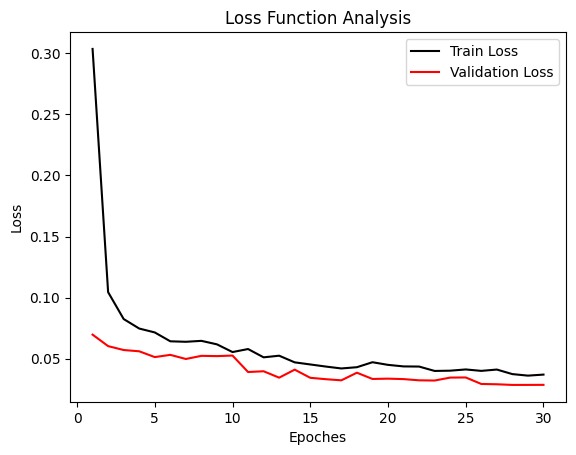

In [12]:
loss_function_analysis(history)

In [13]:
pred = model.predict(train_data)

528/528 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [14]:
errors = np.mean(np.square(train_data-pred),axis = (1,2))

In [15]:
errors

array([0.01784039, 0.01810876, 0.01851289, ..., 0.01229865, 0.01184916,
       0.01216366], shape=(16888,))

In [16]:
results = pd.DataFrame({
    "SID": sensor_ids,
    "location": location,
    "timestamp": window_times,
    "error": errors
})

In [17]:
results

,SID,location,timestamp,error
0,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.017840
1,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.018109
2,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.018513
3,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 12:00:00+00:00,0.017510
4,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-06-30 13:00:00+00:00,0.017458
...,...,...,...,...
16883,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 03:00:00+00:00,0.011840
16884,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 04:00:00+00:00,0.011877
16885,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 21:00:00+00:00,0.012299
16886,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 21:00:00+00:00,0.011849


In [18]:
sensors = list(results['SID'].unique())

In [25]:
#Determine the reconstruction error distribution for each sensor

def anomaly_plot(sensor_id):
    sensor_data = results[results['SID'] == sensor_id]
    sensor_data['timestamp'] = pd.to_datetime(sensor_data['timestamp'])
    sensor_data = sensor_data.sort_values('timestamp')
    location = sensor_data['location'].iloc[0]
    agg = sensor_data.groupby('timestamp', as_index=False)['error'].mean()
    threshold = np.percentile(agg['error'], 95)
    plt.clf()
    plt.plot(agg['timestamp'], agg['error'], label='error')
    plt.axhline(threshold, color='red', linestyle='--', label= f'Threshold: {threshold}')
    anomalies = agg[agg['error'] > threshold]
    plt.scatter(anomalies['timestamp'], anomalies['error'], color='red', s=10, label='anomaly')
    plt.xlabel('Date')
    plt.ylabel('Reconstruction Errors')
    plt.title(f'Anomaly on Sensor at {location}')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

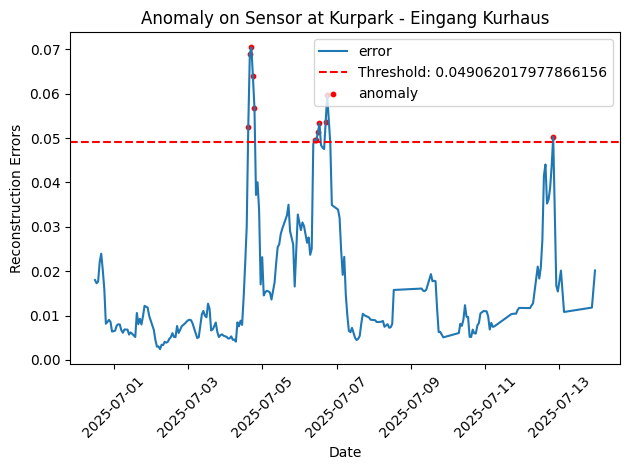

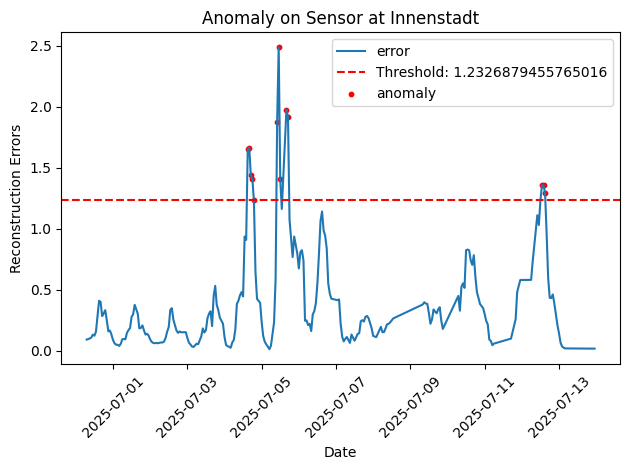

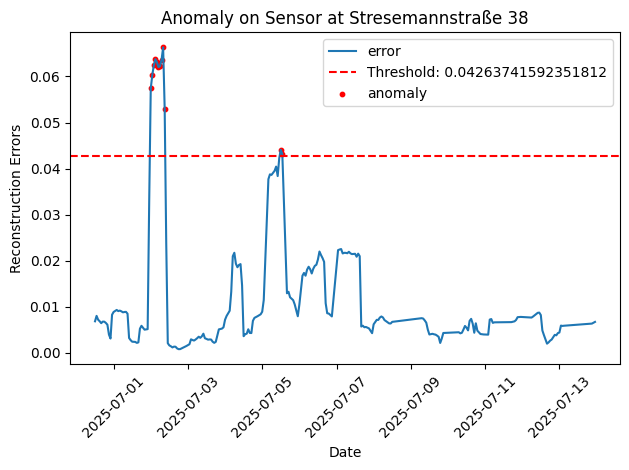

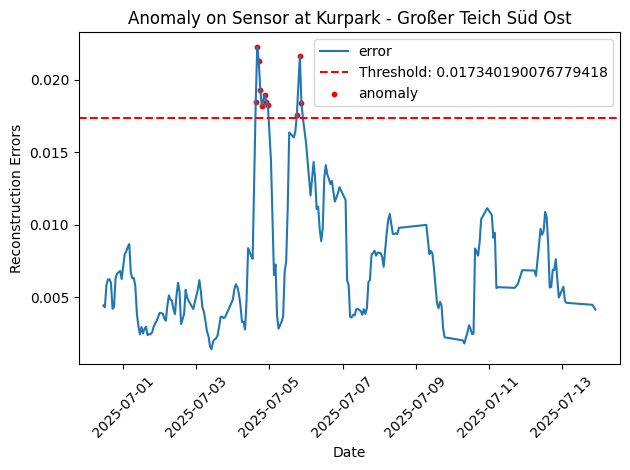

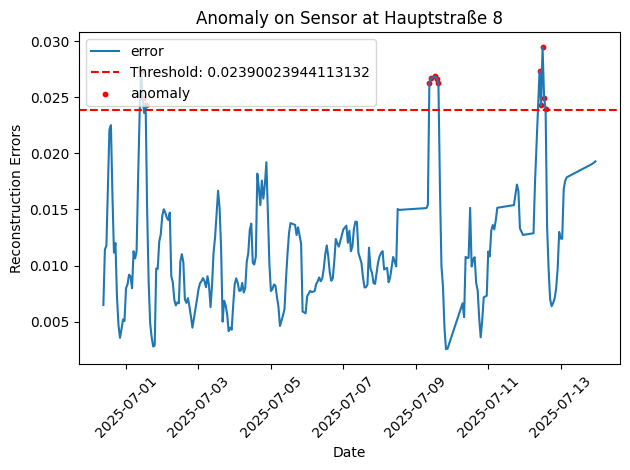

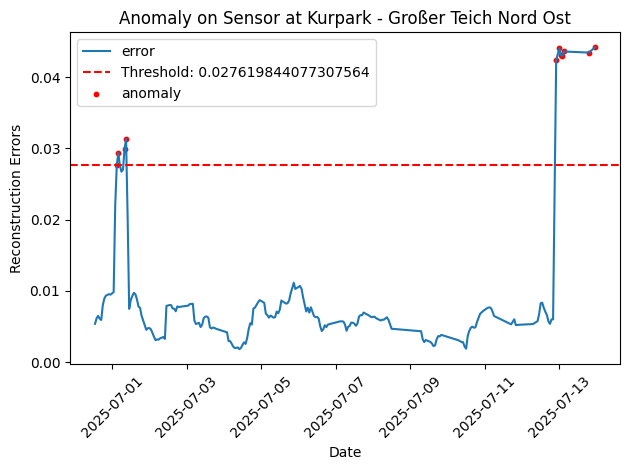

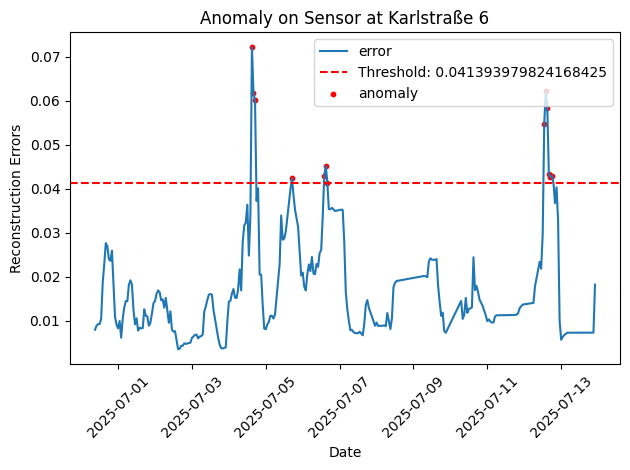

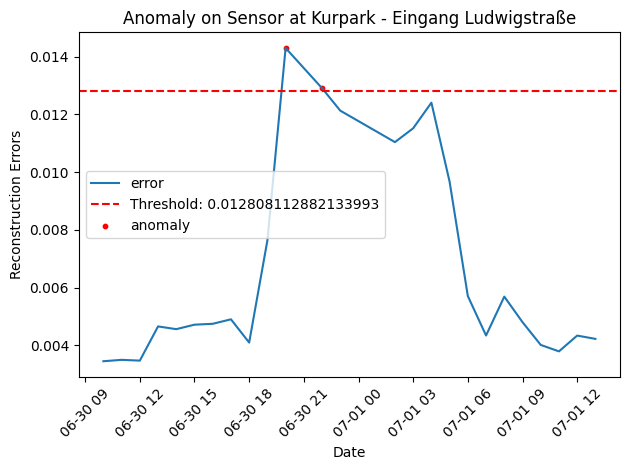

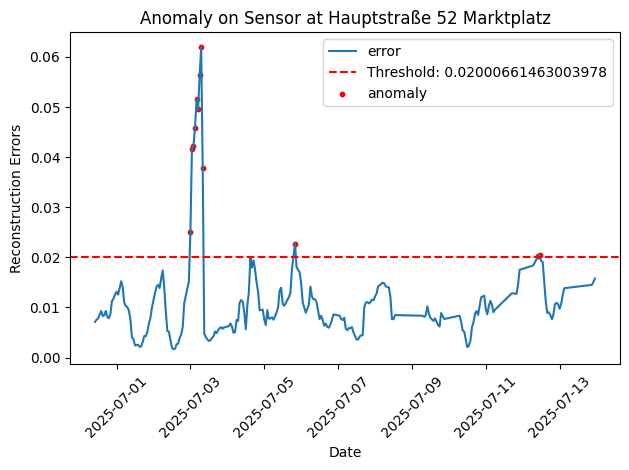

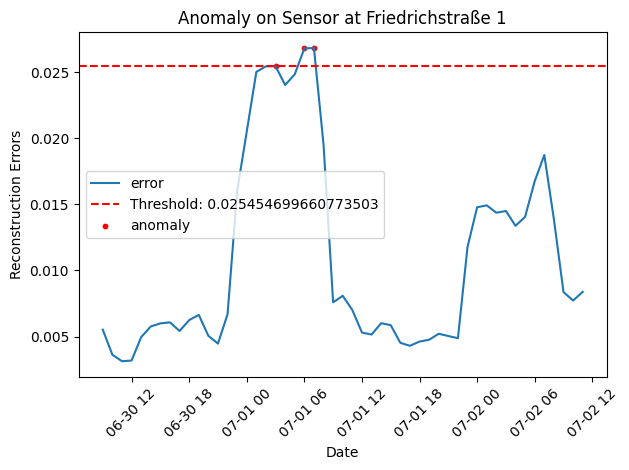

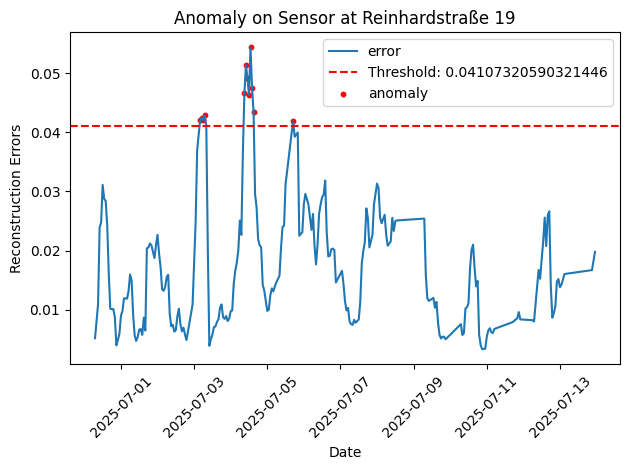

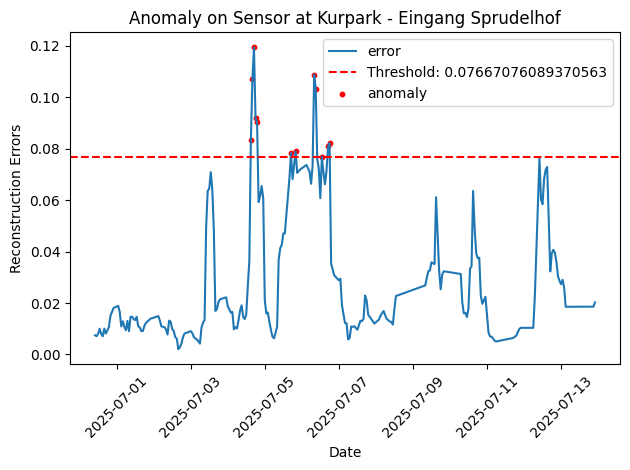

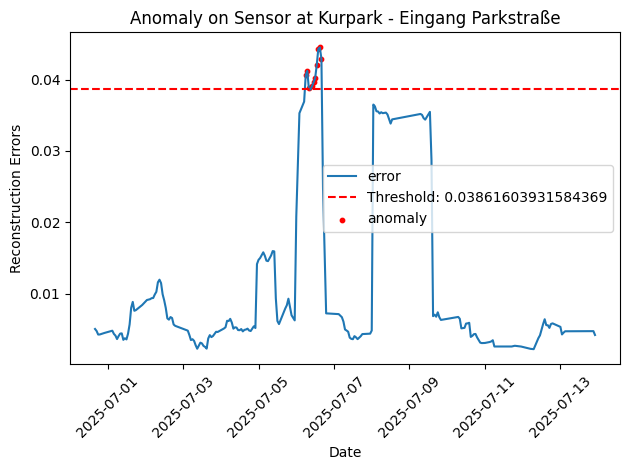

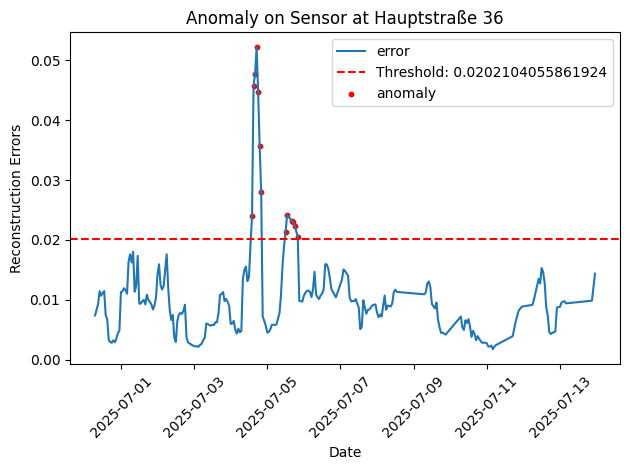

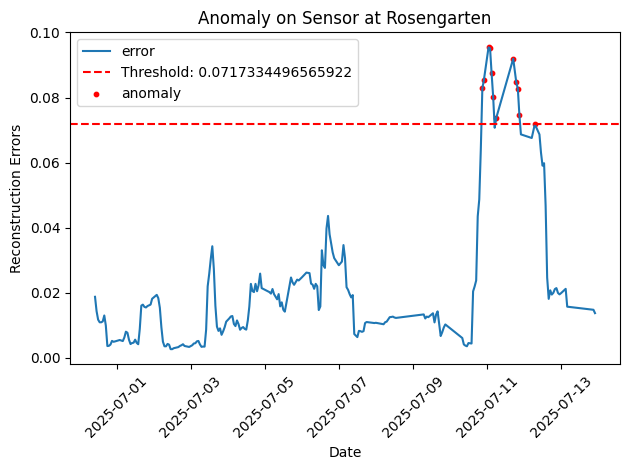

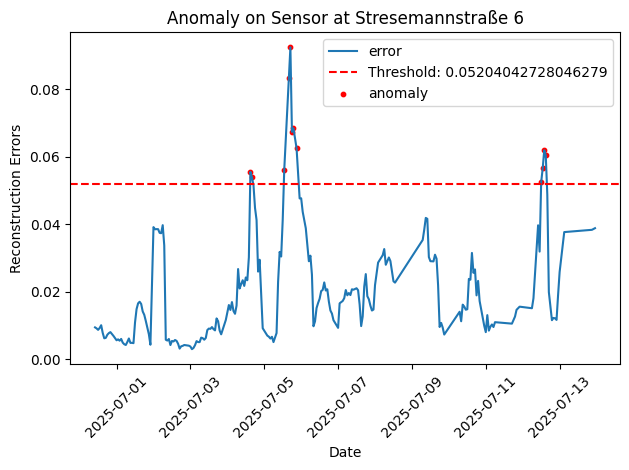

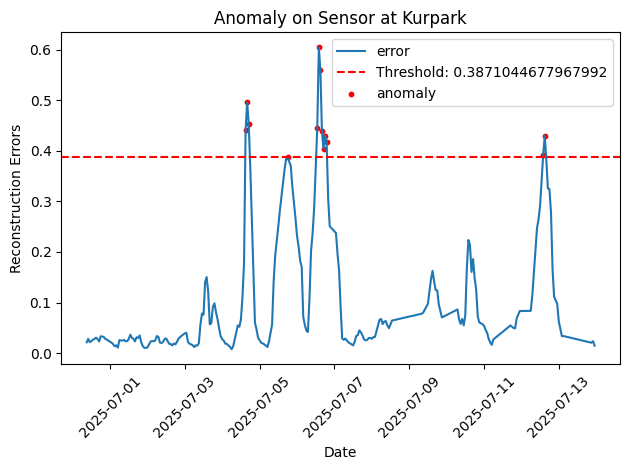

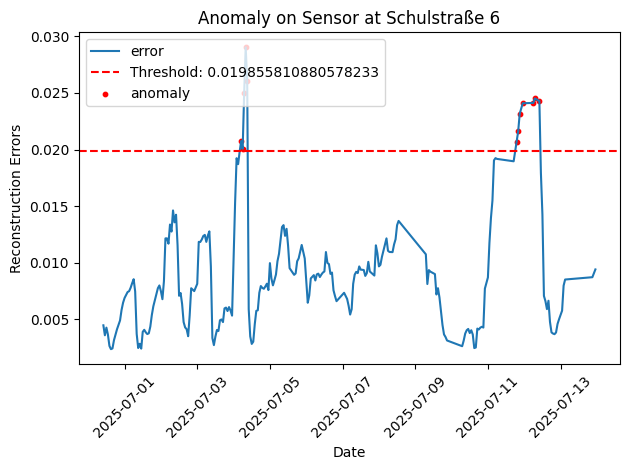

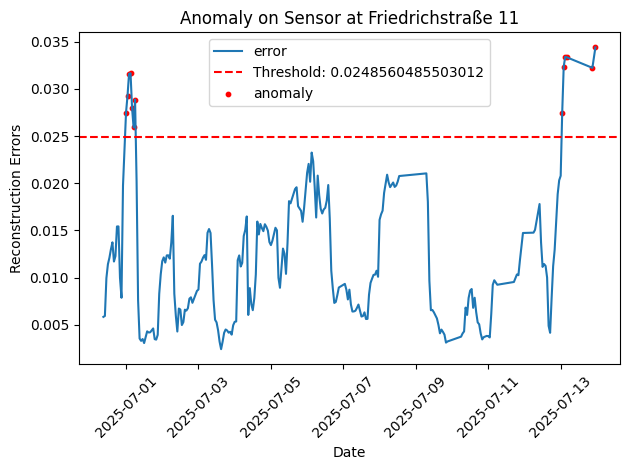

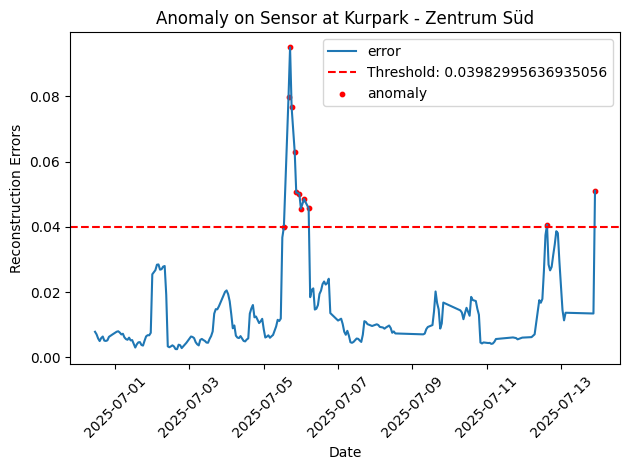

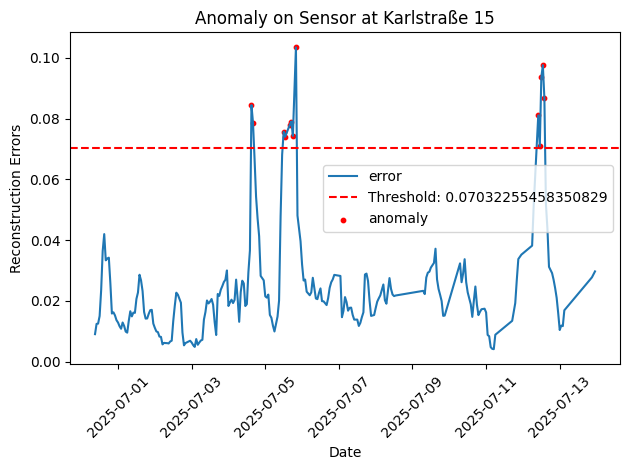

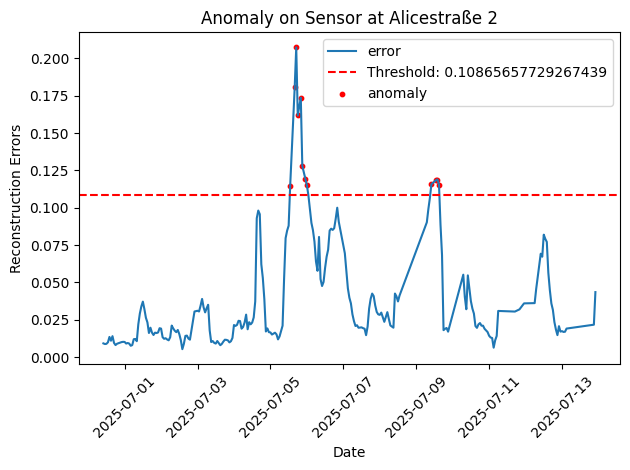

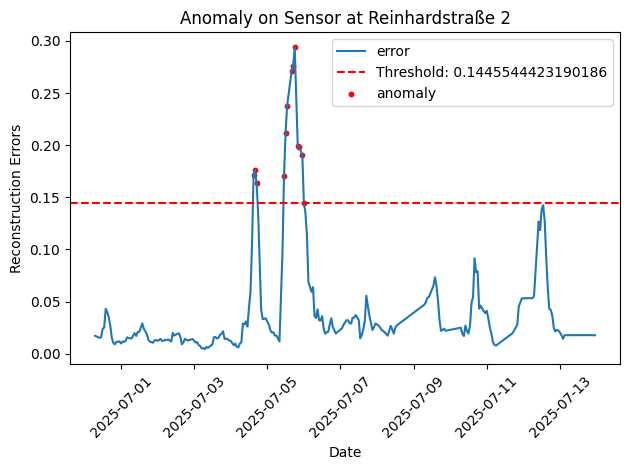

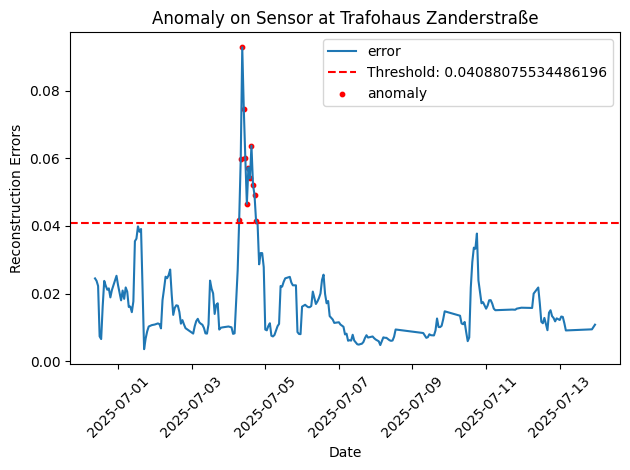

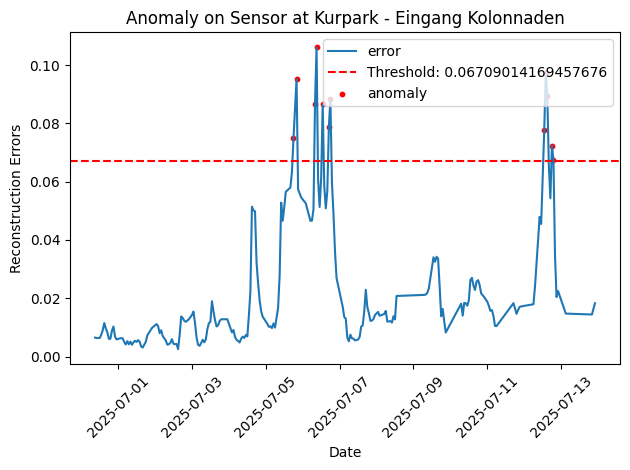

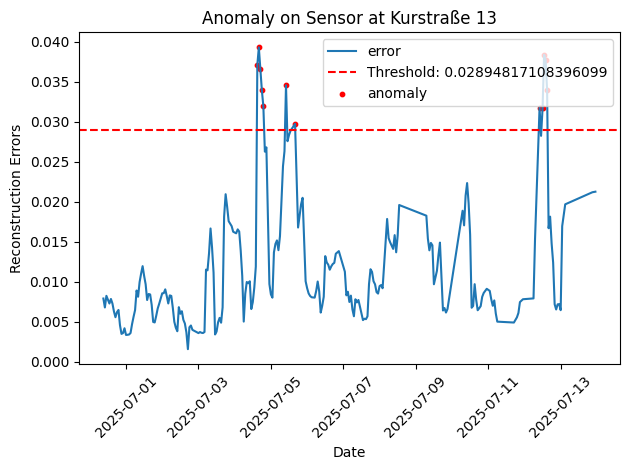

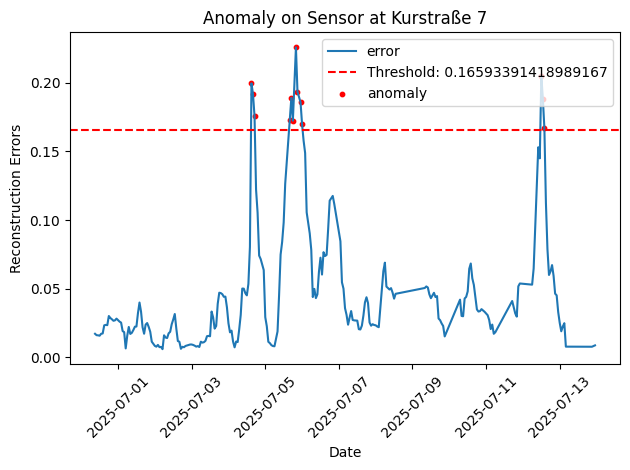

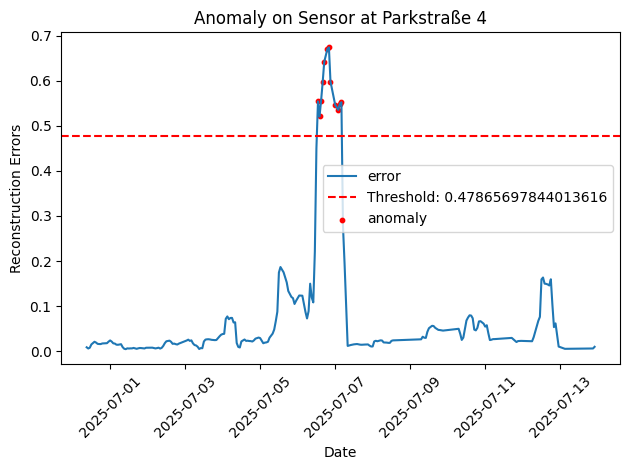

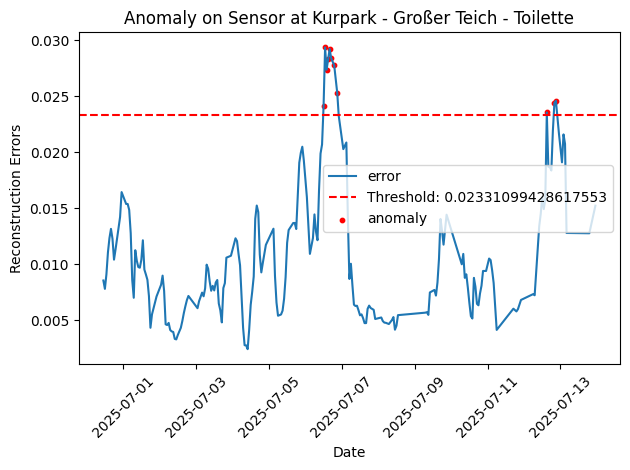

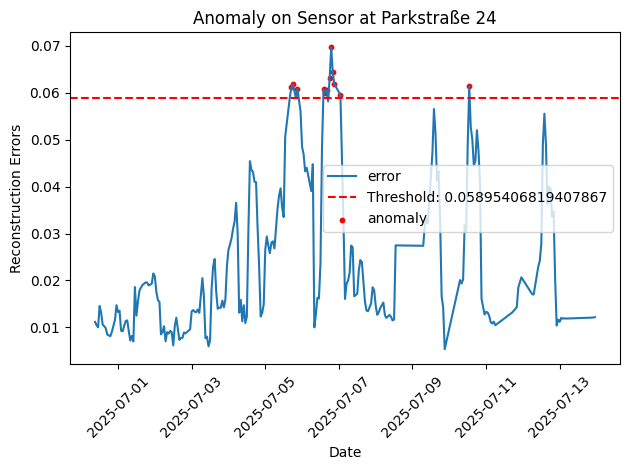

In [26]:
for sensor in sensors:
    anomaly_plot(sensor)

In [21]:
def prepare_anamoly_report(sensor_id:str):
    directory = Path('anomaly_report')
    directory.mkdir(parents = True, exist_ok=True)
    
    sensor_data = results[results['SID'] == sensor_id]
    location = sensor_data['location'].iloc[0]
    sensor_data = sensor_data.groupby('timestamp',as_index=False)['error'].mean()
    threshold = np.percentile(sensor_data['error'],95)
    sensor_data['anomaly'] = np.where(
        sensor_data["error"] > threshold,
        "Yes",
        "No")

    output_file = directory/f"{location}.csv"
    sensor_data.to_csv(output_file)

In [22]:
for sensor in sensors:
    prepare_anamoly_report(sensor)

In [23]:
data[data['name'] == 'Innenstadt'].iloc[225]

Unnamed: 0                                     5125
visitors                                        302
name                                     Innenstadt
avgDuration                                   19.56
timestamp                 2025-07-02 16:00:00+00:00
SID            3cc1e766-97c5-4ed0-92c3-a800b5be8658
weekday                                           2
hour_sin                                  -0.866025
hour_cos                                       -0.5
Name: 5125, dtype: object

In [24]:
#Save model for further use
model.save('global_model.keras')